<a href="https://colab.research.google.com/github/irajamuller/fundamentos_cq/blob/main/UA1_UA2_Circuito_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit --quiet
!pip install qiskit-aer --quiet
!pip install pylatexenc --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 28.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Importação das bibliotecas necessárias
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import array_to_latex, plot_bloch_multivector, plot_bloch_vector
from matplotlib.gridspec import GridSpec

import qiskit.quantum_info as qi
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def get_bloch_vector(rho_reduced):
    """Calcula o vetor de Bloch [x, y, z] a partir da Matriz Densidade reduzida (2x2)."""
    SIGMA_X = np.array([[0, 1], [1, 0]], dtype=complex)
    SIGMA_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    SIGMA_Z = np.array([[1, 0], [0, -1]], dtype=complex)

    rho_data = rho_reduced.data  # Extrai o array numpy 2x2 da Matriz Densidade

    # Componentes do vetor de Bloch
    x = np.trace(np.dot(rho_data, SIGMA_X)).real
    y = np.trace(np.dot(rho_data, SIGMA_Y)).real
    z = np.trace(np.dot(rho_data, SIGMA_Z)).real

    return np.array([x, y, z])


def draw_qc_sphere(qc):
    """Desenha o circuito e a esfera de Bloch de um único qubit."""
    # Estado total
    state = qi.Statevector(qc)
    rho = qi.DensityMatrix(state)
    vector = get_bloch_vector(rho)

    # Vetor de Bloch [x, y, z]
    x, y, z = vector

    # Estado em LaTeX
    latex_string = state.draw('latex')._repr_latex_()
    latex_string = latex_string.replace('$$', '').replace('\\n', ' ')
    latex_string = latex_string.replace('\\begin{pmatrix}', '\\begin{array}')
    latex_string = latex_string.replace('\\end{pmatrix}', '\\end{array}')
    latex_state = r'$|\psi\rangle = ' + latex_string.strip() + r'$'

    # Figura principal
    fig_main = plt.figure(figsize=(10, 5))
    gs = GridSpec(1, 3, figure=fig_main)

    # Texto LaTeX
    axs_text = fig_main.add_subplot(gs[0, 0])
    axs_text.axis('off')
    fig_main.text(0.12, 0.5, latex_state, fontsize=16, ha='center', va='center')

    # Circuito
    axs_circ = fig_main.add_subplot(gs[0, 1])
    qc.draw('mpl', ax=axs_circ, scale=1.2)
    axs_circ.set_title("Circuito Quântico", fontsize=14)

    # Esfera de Bloch
    axs_bloch = fig_main.add_subplot(gs[0, 2], projection='3d')
    plot_bloch_vector([x, y, z], ax=axs_bloch)
    axs_bloch.set_title("qubit 0", fontsize=12, y=1.08)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Criando circuito de 1 qubit

In [ ]:
# Cria circuito quântico com 1 qubit no estado fundamental |0>
qc = QuantumCircuit(1)

### Aplicando a porta Hadamard
$H=\frac{1}{\sqrt{2}} \begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}$

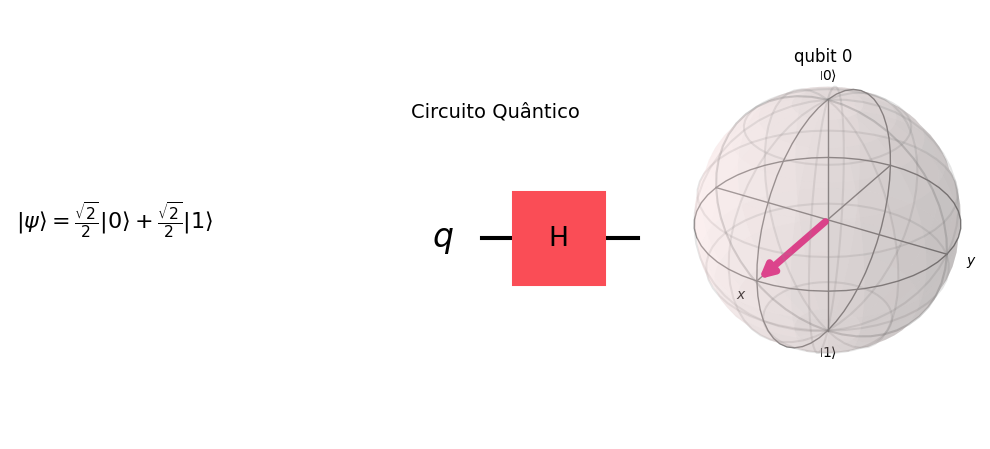

In [ ]:
# Aplica a porta hadamard no qubit, resultando em um estado de superposição máxima
# Observa-se que estamos mudando de base
qc.h(0)
draw_qc_sphere(qc) #qi.Statevector(qc).draw('latex')

### Aplicando a porta de fase S
$S=\begin{pmatrix}
1 & 0 \\
0 & i
\end{pmatrix}$

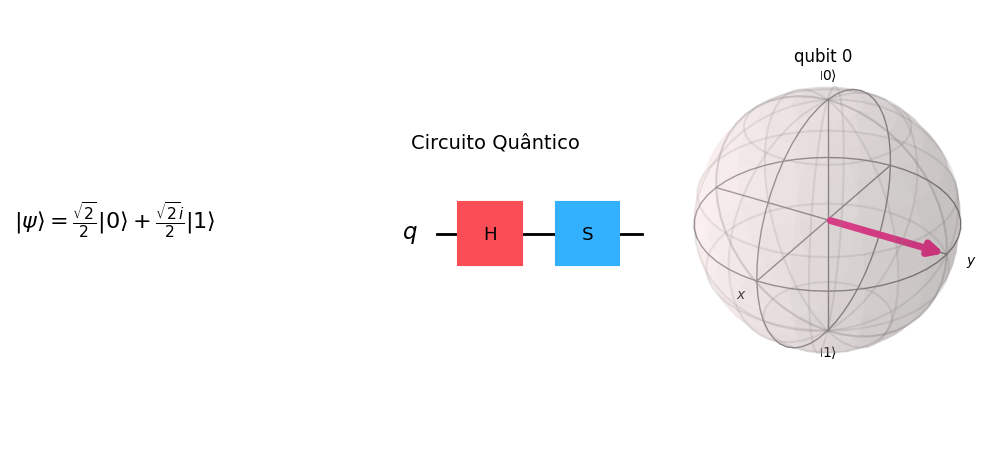

In [ ]:
# Aplica a porta de fase (S) adicionando uma fase complexa ao estado |1>
# O qubit está em superposição mas agora com uma fase complexa
qc.s(0)
draw_qc_sphere(qc) #qi.Statevector(qc).draw('latex')

### Aplicando a porta Pauli-Y
$Y=\begin{pmatrix}
0 & -i \\
i & 0
\end{pmatrix}$

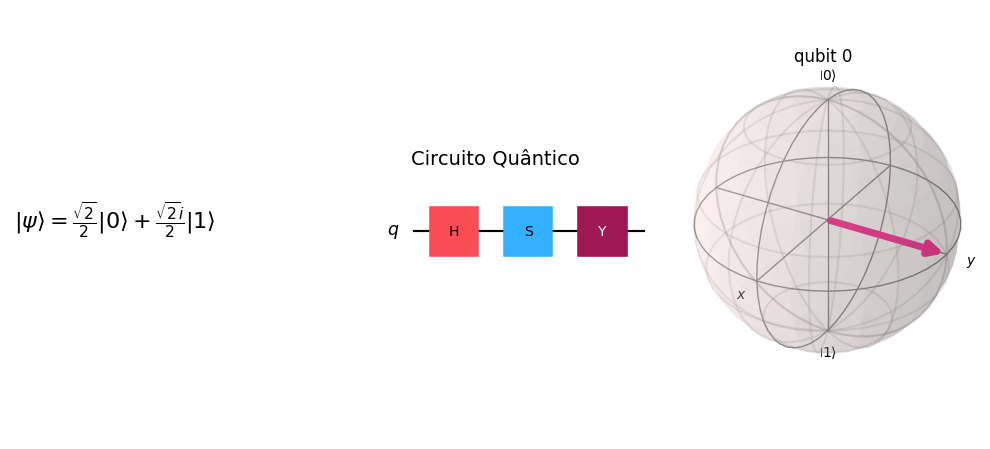

In [ ]:
# A porta Pauli-Y é similar à Pauli-X mas com "mudança" de fase complexa.
# Contudo, como já existe a fase no estado atual, não terá efeito (swap).
qc.y(0)
draw_qc_sphere(qc) #qi.Statevector(qc).draw('latex')

### Aplicando a porta de rotação $R_x(\pi/4)$

$R_x(\theta)=\begin{pmatrix}
cos\frac{\theta}{2} & -isin\frac{\theta}{2} \\
-isin\frac{\theta}{2} & cos\frac{\theta}{2}
\end{pmatrix}$

$R_x(\pi/4)=\begin{pmatrix}
cos\frac{\pi}{8} & -isin\frac{\pi}{8} \\
-isin\frac{\pi}{8} & cos\frac{\pi}{8}
\end{pmatrix}$

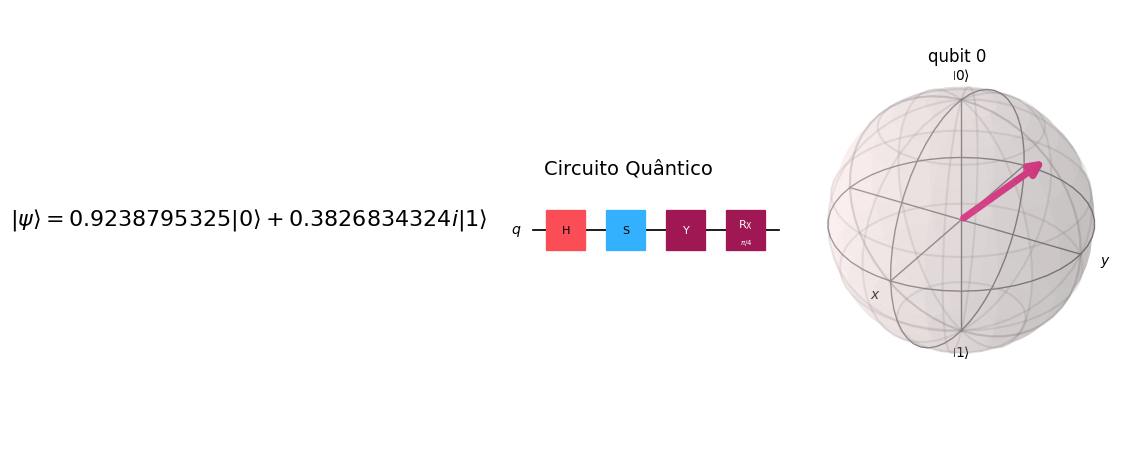

In [ ]:
# A porta de rotação sobre o eixo X tem como parâmetro pi / 4.
# Nesse cenário, ocorrerá uma rotação em torno do eixo X em um ângulo de 45 graus
qc.rx(np.pi / 4, 0)
draw_qc_sphere(qc) #qi.Statevector(qc).draw('latex')

### Aplicando a porta de rotação $R_y(\pi)$
$R_y(\theta)=\begin{pmatrix}
cos\frac{\theta}{2} & -sin\frac{\theta}{2} \\
sin\frac{\theta}{2} & cos\frac{\theta}{2}
\end{pmatrix}$

$R_y(\pi)=\begin{pmatrix}
cos \frac{\pi}{2} & -sin\frac{\pi}{2} \\
sin\frac{\pi}{2} & cos\frac{\pi}{2}
\end{pmatrix}$ = $\begin{pmatrix}
0 & -1 \\
1 & 0
\end{pmatrix}$

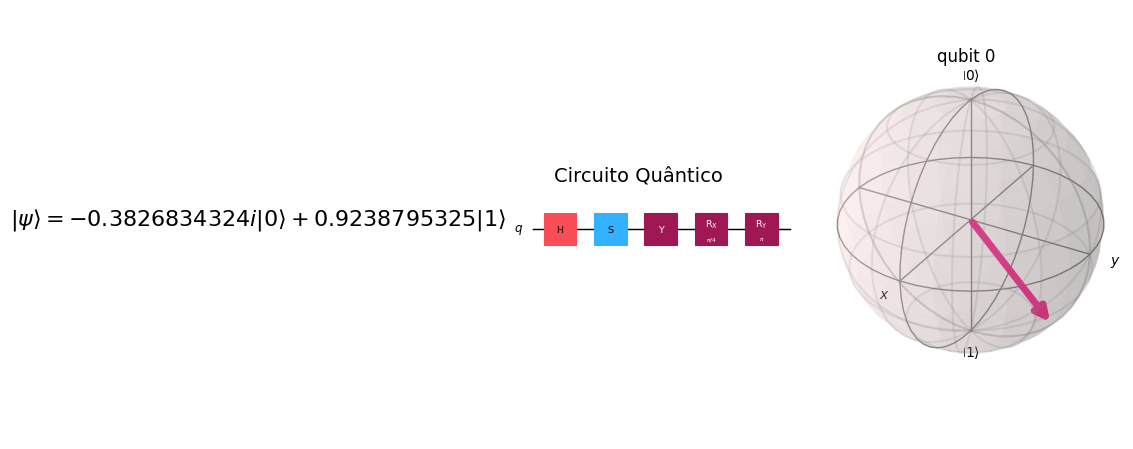

In [ ]:
# A porta de rotação sobre o eixo y tem como parâmetro pi.
# Com o theta = pi, essa porta é similar à Pauli-X mas com mudança de fase.
# Nesse cenário, ocorrerá uma rotação em torno do eixo Y em 180 graus.
qc.ry(np.pi, 0)
draw_qc_sphere(qc) #qi.Statevector(qc).draw('latex')